In this notebook, we generate finite element data for training neural operators.

### General Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

In [2]:
from mesher import Mesh2D
from conditions import BoundaryCondition
from materials import LinearElastic, NLElasticMatrix
from solver import NFEA

In [3]:
from scipy.spatial import cKDTree

def get_periodic_pairs_kdtree(mesh, delta_x: float = None, delta_y: float = None, tol=1e-8):
    """
    Finds periodic node pairs (Left-Right, Bottom-Top) using KD-Tree for fast spatial querying.
    
    Args:
        mesh: Mesh2D object containing coordinates, dimensions (lx, ly), and node groups.
        tol (float): Spatial tolerance for matching nodes.
        
    Returns:
        tuple: Two lists of paired node IDs (1-based format) -> (pairs_left_right, pairs_bottom_top).
    """
    # Get all coordinates as a numpy array
    coords = np.array(mesh.coordinates)
    
    if delta_x is None:
        delta_x = max(coords[:, 0]) - min(coords[:, 0])
    if delta_y is None:
        delta_y = max(coords[:, 1]) - min(coords[:, 1])

    # Extract 0-based indices for boundary nodes (Mesh2D uses 1-based IDs)
    left_idx = np.array(list(mesh.node_groups['Xmin_n'])) - 1
    right_idx = np.array(list(mesh.node_groups['Xmax_n'])) - 1
    bottom_idx = np.array(list(mesh.node_groups['Ymin_n'])) - 1
    top_idx = np.array(list(mesh.node_groups['Ymax_n'])) - 1
    
    coords_left, coords_right = coords[left_idx], coords[right_idx]
    coords_bottom, coords_top = coords[bottom_idx], coords[top_idx]
    
    # ---------------------------------------------------------
    # LEFT-RIGHT PAIRING (X-axis)
    # ---------------------------------------------------------
    # Shift left boundary nodes by Lx to overlap the right boundary
    shifted_left = coords_left.copy()
    shifted_left[:, 0] += delta_x  
    
    # Build KD-Tree for right boundary and query matches
    tree_right = cKDTree(coords_right)
    distances_lr, indices_lr = tree_right.query(shifted_left, distance_upper_bound=tol)
    valid_lr = distances_lr < tol
    
    # Construct pairs and restore 1-based indexing
    left_nodes = (left_idx[valid_lr] + 1).tolist()
    right_nodes = (right_idx[indices_lr[valid_lr]] + 1).tolist()

    pairs_left_right = list(zip(left_nodes, right_nodes))
    
    # ---------------------------------------------------------
    # BOTTOM-TOP PAIRING (Y-axis)
    # ---------------------------------------------------------
    # Shift bottom boundary nodes by Ly to overlap the top boundary
    shifted_bottom = coords_bottom.copy()
    shifted_bottom[:, 1] += delta_y 
    
    # Build KD-Tree for top boundary and query matches
    tree_top = cKDTree(coords_top)
    distances_bt, indices_bt = tree_top.query(shifted_bottom, distance_upper_bound=tol)
    valid_bt = distances_bt < tol
    
    # Construct pairs and restore 1-based indexing
    bottom_nodes = (bottom_idx[valid_bt] + 1).tolist()
    top_nodes = (top_idx[indices_bt[valid_bt]] + 1).tolist()    
    
    pairs_bottom_top = list(zip(bottom_nodes, top_nodes))
    
    return pairs_left_right, pairs_bottom_top

In [4]:
from conditions import PeriodicBoundaryCondition
import torch
from utils import QuadShapeFunctions

# Material properties

# Soft matrix
tag_soft = 0
K_m = 4_780      # MPa
alpha_1 = 5.0e1   # MPa
alpha_2 = 6.0e-2  # Dimensionless

# Hard fiber
tag_hard = 1 
K_f = 43_500      # MPa
G_f = 29_900      # MPa

# Convert Bulk (K) and Shear (G) moduli to Young's modulus (E) and Poisson's ratio (nu)
E_hard = (9.0 * K_f * G_f) / (3.0 * K_f + G_f)
nu_hard = (3.0 * K_f - 2.0 * G_f) / (2.0 * (3.0 * K_f + G_f))

soft = NLElasticMatrix(Km=K_m, alpha1=alpha_1, alpha2=alpha_2, tag=tag_soft)
hard = LinearElastic(emod=E_hard, nu=nu_hard, tag=tag_hard)

# RVE dimensions
delta_x = 0.10      # RVE size in X direction in (mm)
delta_y = 0.10      # RVE size in Y direction in (mm)

# Configuration of input/output paths
meshes_folder = Path("../meshes")
strain_folder = Path("../strain_histories")

mesh_files  = sorted(meshes_folder.glob("*.med"))               # mesh 1, mesh 2, ...
strain_files = sorted(strain_folder.glob("strain_*.csv"))       # strain_1.csv, strain_2.csv, ...

output_dir = Path("../data/Run2")
output_dir.mkdir(parents=True, exist_ok=True)

# batch to solve
b_ini = 1           # inclusive
b_end = 1000        # inclusive

# Loop over batches
for idx in range(b_ini, b_end + 1):
    if idx < b_ini:
        continue
    if idx > b_end:
        break
    
    mesh_file = mesh_files[idx-1]
    strain_file = strain_files[idx-1]

    print(f"Processing {idx}/{b_end} → {mesh_file.name}")
    
    # Read mesh
    mesh = Mesh2D.from_salome_med(filepath=mesh_file, verbose=False)

    left_right_pairs, bottom_top_pairs = get_periodic_pairs_kdtree(mesh, delta_x=delta_x, delta_y=delta_y)

    # Define boundary conditions
    bcs = {
        'fixed_n': [BoundaryCondition(dof=1, value=0.0),
                    BoundaryCondition(dof=2, value=0.0)],  
        }
    
    # Define periodic boundary conditions
    strain_data = np.genfromtxt(
            strain_file,
            delimiter=',',
            names=True,
            dtype=float,
            skip_header=0
        )

    exx = strain_data['exx']
    eyy = strain_data['eyy']
    gxy = strain_data['gxy']
    n_steps = len(exx)
    
    pbc = PeriodicBoundaryCondition(
        exx=exx[0],
        eyy=eyy[0],
        gxy=gxy[0],
        left_right_pairs=left_right_pairs,
        bottom_top_pairs=bottom_top_pairs,
        delta_x=delta_x,
        delta_y=delta_y
        )

    mpcs = pbc.get_constraints()

    # Define material field mapping
    matfield = {'soft_s': soft, 
                'hard_s': hard}

    # Instance FEA solver
    fem_solver = NFEA(mesh = mesh, 
                      bcs = bcs,
                      matfld = matfield,
                      mpcs=mpcs,
                      verbose = False,
                      device = 'cpu'
                      )
    
    rve_file = output_dir / f"rve_{idx:04d}.h5"
    nchannels = 4   # phase_field (0=soft, 1=hard), sXX, sYY, sXY
    nmacro = 3      # exx, eyy, gxy

    N_total = n_steps - 1 
    nelx = int(np.sqrt(fem_solver.nelem))
    nely = nelx                          
    ngp = 2
    H_gp = nely * ngp
    W_gp = nelx * ngp

    # Pre-calculate and store static GP data (coordinates + phase) for all groups
    gp_static_list = []
    for group_name, batch in fem_solver.quad_batches.items():
        tag_val = float(batch.material.tag)
        
        # Physical coordinates of Gauss points
        H_shape = QuadShapeFunctions(batch.r_gp, batch.s_gp, batch.nnode)
        X_gp = torch.einsum('gn,enj->egj', H_shape, batch.X)
        coords_flat = X_gp.reshape(-1, 2).cpu().numpy()
        
        # Phase (0.0 o 1.0)
        phase_val = 1.0 if tag_val == tag_hard else 0.0
        phase_flat = np.full((len(coords_flat), 1), phase_val, dtype=np.float32)
        
        gp_static_list.append(np.hstack([coords_flat, phase_flat]))
    
    gp_static_array = np.vstack(gp_static_list)
    x_coords = np.round(gp_static_array[:, 0], decimals=5)
    y_coords = np.round(gp_static_array[:, 1], decimals=5)
    sort_idx = np.lexsort((x_coords, y_coords)) 
    
    phase_grid = gp_static_array[sort_idx, 2].reshape(H_gp, W_gp)

    with h5py.File(rve_file, 'w') as f:
        # Create datasets
        f.create_dataset('fields', 
                                 shape=(N_total, H_gp, W_gp, nchannels),
                                 dtype=np.float32, 
                                 compression='gzip', compression_opts=4)
        f.create_dataset('macro', 
                                 shape=(N_total, nmacro),
                                 dtype=np.float32, compression='gzip')
        # Save metadata
        f.attrs.update({
            'H_gp': H_gp, 
            'W_gp': W_gp, 
            'ngp': ngp, 
            'n_steps': N_total,
            'mesh_name': mesh_file.name,
            'description': 'Dual-Encoder FNO: '
                        'fields[phase(0=soft,1=hard), sXX, sYY, sXY] + '
                        'macro[exx, eyy, gxy]'
        })

        # Loop over steps
        for step in range(1, n_steps):
            pbc.update_strains(new_exx=exx[step], new_eyy=eyy[step], new_gxy=gxy[step])
            fem_solver.update_mpc_b0s()
            fem_solver.run_complete(nsteps=1)

            # Compute stress at Gauss points for all groups
            sigma_list = []
            for group_name, batch in fem_solver.quad_batches.items():
                u_local = batch.get_local_disp(fem_solver.udisp)
                eps_gp = batch.compute_infinitesimal_strain(u_local)
                state_gp = batch.state
                sigma_gp, _, _ = batch.material.update_state(eps_gp, state_gp, isTangent=False)
                sigma_list.append(sigma_gp.reshape(-1, 3).cpu().numpy())

            sigma_flat = np.vstack(sigma_list)
            sigma_sorted = sigma_flat[sort_idx]

            # Reshape to structured grid
            data_step = np.zeros((H_gp, W_gp, nchannels), dtype=np.float32)
            data_step[..., 0] = phase_grid
            data_step[..., 1] = sigma_sorted[:, 0].reshape(H_gp, W_gp) # sXX
            data_step[..., 2] = sigma_sorted[:, 1].reshape(H_gp, W_gp) # sYY
            data_step[..., 3] = sigma_sorted[:, 2].reshape(H_gp, W_gp) # sXY

            # Global features
            macro_step = np.array([
                    exx[step], eyy[step], gxy[step],   # macro strain
                ], dtype=np.float32)

            # Save
            f['fields'][step-1]     = data_step
            f['macro'][step-1]      = macro_step

print(f"\n Process finished. Files saved at:\n{output_dir}")

Processing 1/1000 → RVE_8x8_f0.40_0001.med
Processing 2/1000 → RVE_8x8_f0.40_0002.med
Processing 3/1000 → RVE_8x8_f0.40_0003.med
Processing 4/1000 → RVE_8x8_f0.40_0004.med
Processing 5/1000 → RVE_8x8_f0.40_0005.med
Processing 6/1000 → RVE_8x8_f0.40_0006.med
Processing 7/1000 → RVE_8x8_f0.40_0007.med
Processing 8/1000 → RVE_8x8_f0.40_0008.med
Processing 9/1000 → RVE_8x8_f0.40_0009.med
Processing 10/1000 → RVE_8x8_f0.40_0010.med
Processing 11/1000 → RVE_8x8_f0.40_0011.med
Processing 12/1000 → RVE_8x8_f0.40_0012.med
Processing 13/1000 → RVE_8x8_f0.40_0013.med
Processing 14/1000 → RVE_8x8_f0.40_0014.med
Processing 15/1000 → RVE_8x8_f0.40_0015.med
Processing 16/1000 → RVE_8x8_f0.40_0016.med
Processing 17/1000 → RVE_8x8_f0.40_0017.med
Processing 18/1000 → RVE_8x8_f0.40_0018.med
Processing 19/1000 → RVE_8x8_f0.40_0019.med
Processing 20/1000 → RVE_8x8_f0.40_0020.med
Processing 21/1000 → RVE_8x8_f0.40_0021.med
Processing 22/1000 → RVE_8x8_f0.40_0022.med
Processing 23/1000 → RVE_8x8_f0.40_0023.m

In [7]:
# ==================== CHECK FILE ====================

def check_rve_data(rve_file):
    with h5py.File(rve_file, 'r') as f:
        print("✅ File opened successfully")
        print("Available keys        :", list(f.keys()))
        print("File attributes       :")
        for key, val in f.attrs.items():
            print(f"   {key:15} = {val}")
        
        # Datasets
        fields = f['fields'][:]      # (N_steps, H, W, nchannels)
        macro  = f['macro'][:]       # (N_steps, nmacro)
        
        print("\n📊 Shapes:")
        print(f"   fields → {fields.shape}  → [phase(0=soft,1=hard), Sxx, Syy, Sxy]")
        print(f"   macro  → {macro.shape}   → [exx, eyy, gxy, E_soft, nu_soft, E_hard, nu_hard]")
        
        H, W = fields.shape[1], fields.shape[2]
        print(f"\n🔍 Grid check: {H}×{W} → {'✅ OK' if H == W else '❌ Not square'}")
        
        # Check phases
        phase_unique = np.unique(fields[0, :, :, 0])
        print(f"   Unique phases: {phase_unique} → {'✅ Correct' if len(phase_unique)==2 else '❌'}")
        
        # First macro values
        print(f"   First macro: exx={macro[0,0]:.6f}, "
              f"eyy={macro[0,1]:.6f}, "
              f"gxy={macro[0,2]:.6f}")

        return fields, macro

# Test
rve_file = "../data/Run2/rve_0001.h5"
fields, macro = check_rve_data(rve_file)

✅ File opened successfully
Available keys        : ['fields', 'macro']
File attributes       :
   H_gp            = 96
   W_gp            = 96
   description     = Dual-Encoder FNO: fields[phase(0=soft,1=hard), sXX, sYY, sXY] + macro[exx, eyy, gxy]
   mesh_name       = RVE_8x8_f0.40_0001.med
   n_steps         = 100
   ngp             = 2

📊 Shapes:
   fields → (100, 96, 96, 4)  → [phase(0=soft,1=hard), Sxx, Syy, Sxy]
   macro  → (100, 3)   → [exx, eyy, gxy, E_soft, nu_soft, E_hard, nu_hard]

🔍 Grid check: 96×96 → ✅ OK
   Unique phases: [0. 1.] → ✅ Correct
   First macro: exx=0.000016, eyy=0.000014, gxy=0.000000


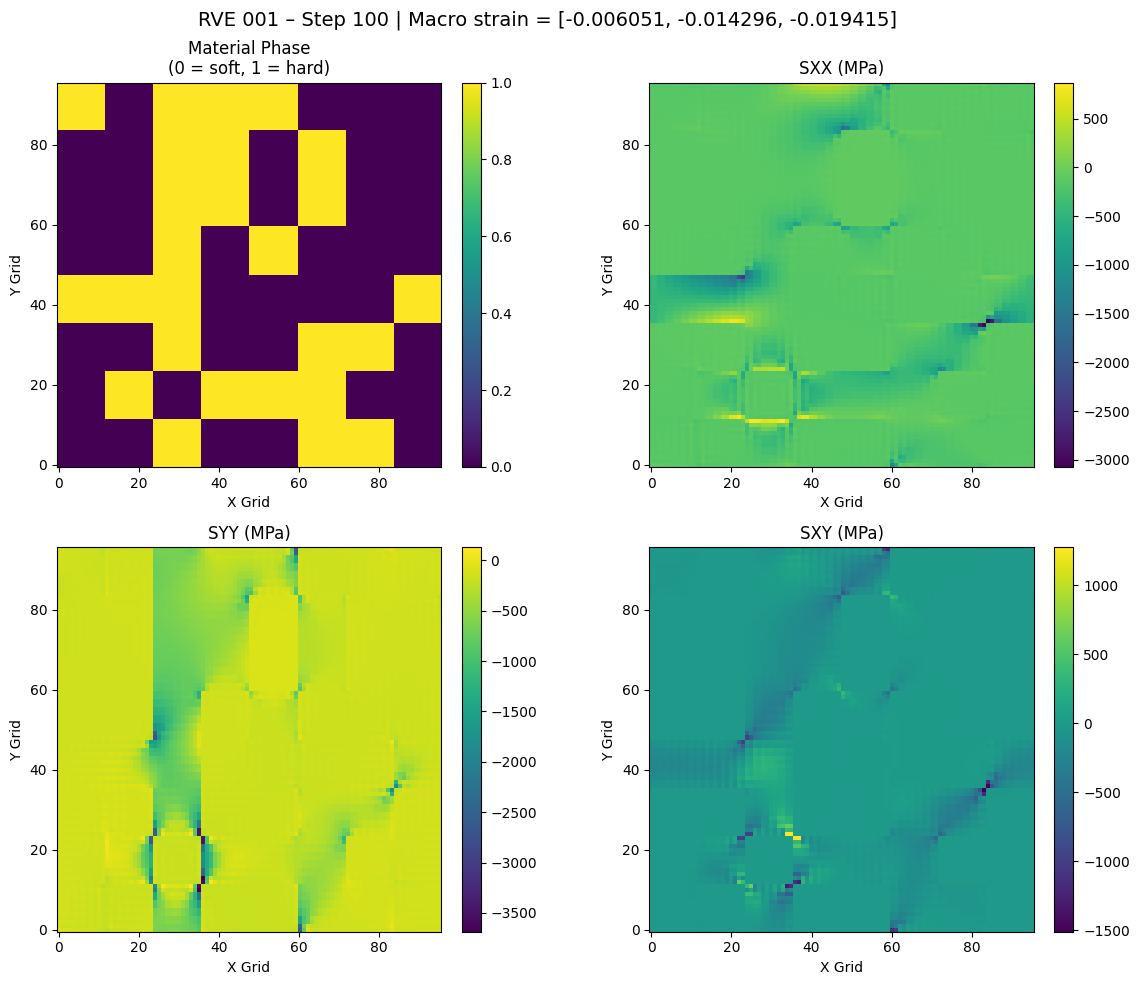

In [8]:
# ==================== PLOTS ====================

def plot_fields(fields, macro, step=-1):
    """
    Plot fields and macro strain for a given step.
    fields: (N_steps, H, W, 4) → [phase, Sxx, Syy, Sxy]
    macro:  (N_steps, 7)      → [exx, eyy, gxy, E_soft, nu_soft, E_hard, nu_hard]
    """
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    titles = [
        "Material Phase\n(0 = soft, 1 = hard)",
        "SXX (MPa)",
        "SYY (MPa)",
        "SXY (MPa)"
    ]
    
    data = [
        fields[step-1, :, :, 0],   # phase
        fields[step-1, :, :, 1],   # σxx
        fields[step-1, :, :, 2],   # σyy
        fields[step-1, :, :, 3]    # σxy
    ]

    for i, ax in enumerate(axs.flat):
        im = ax.imshow(data[i], cmap='viridis', origin='lower')
        ax.set_title(titles[i])
        ax.set_xlabel('X Grid')
        ax.set_ylabel('Y Grid')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Show only macro strain components in title
    eps = macro[step-1, :3]  # exx, eyy, gxy
    plt.suptitle(f'RVE 001 – Step {step} | '
                 f'Macro strain = [{eps[0]:.6f}, {eps[1]:.6f}, {eps[2]:.6f}]',
                 fontsize=14)
    
    plt.tight_layout()
    plt.show()


# Test
plot_fields(fields, macro, step=100)